In [1]:
%pip install torch torchvision ultralytics matplotlib scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
class FolderYoloDataset(Dataset):
    """Binary classification dataset based on YOLO folder structure, reusing the logic from defect_cnn.ipynb.
    Rule: if any class_id == 0 exists in the label txt file, the image is treated as defective (label=0),
    otherwise it is treated as normal (label=1).
    """
    def __init__(self, split_root, transform=None):
        self.split_root = split_root
        self.images_dir = os.path.join(split_root, "images")
        self.labels_dir = os.path.join(split_root, "labels")
        self.transform = transform

        self.label_files = sorted(
            [
                os.path.join(self.labels_dir, f)
                for f in os.listdir(self.labels_dir)
                if f.endswith(".txt")
            ]
        )

    def __len__(self):
        return len(self.label_files)

    def _find_image_path(self, label_path):
        stem = os.path.splitext(os.path.basename(label_path))[0]
        for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
            img_path = os.path.join(self.images_dir, stem + ext)
            if os.path.exists(img_path):
                return img_path
        raise FileNotFoundError(f"No image found for label file: {label_path}")

    def __getitem__(self, idx):
        label_path = self.label_files[idx]
        img_path = self._find_image_path(label_path)

        class_ids = []
        with open(label_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                class_id = int(parts[0])
                class_ids.append(class_id)

        if not class_ids:
            label = 1.0
        else:
            label = 0.0 if any(cid == 0 for cid in class_ids) else 1.0

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)
        return image, label

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Root directory
root_dir = r"c:\Users\user\Documents\Computer vision\data"

train_root = os.path.join(root_dir, "train")
val_root   = os.path.join(root_dir, "valid")

train_dataset = FolderYoloDataset(train_root, transform=train_transform)
val_dataset   = FolderYoloDataset(val_root,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

len(train_dataset), len(val_dataset)


(291, 71)

In [4]:
from torchvision import models

class SSLBackbone(nn.Module):
    """Backbone placeholder for self-supervised feature extraction using a ResNet50 architecture.
    In practice, you can replace the randomly initialized weights with your own self-supervised pretrained weights.
    """
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=None)  # Do not load ImageNet weights; easier to compare with SSL weights
        self.encoder = nn.Sequential(*list(base.children())[:-1])  # Remove the final fully-connected layer
        self.out_dim = 2048

    def forward(self, x):
        x = self.encoder(x)   # [B, 2048, 1, 1]
        x = x.flatten(1)      # [B, 2048]
        return x

class SSLClassifier(nn.Module):
    def __init__(self, backbone: SSLBackbone):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(self.backbone.out_dim, 1)  # Binary classification: defective / normal

    def forward(self, x):
        feats = self.backbone(x)
        logits = self.head(feats)
        return logits.squeeze(1)

backbone = SSLBackbone()

ssl_model = SSLClassifier(backbone).to(device)
ssl_model


SSLClassifier(
  (backbone): SSLBackbone(
    (encoder): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)

In [5]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(ssl_model.parameters(), lr=1e-4)

train_losses = []
val_accuracies = []

def evaluate(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc

num_epochs = 20
for epoch in range(num_epochs):
    ssl_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = ssl_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)
    val_acc = evaluate(ssl_model, val_loader)

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/20, Train Loss: 0.4919, Val Acc: 0.5775
Epoch 2/20, Train Loss: 0.2341, Val Acc: 0.5775
Epoch 3/20, Train Loss: 0.0908, Val Acc: 0.8873
Epoch 4/20, Train Loss: 0.0487, Val Acc: 0.9718
Epoch 5/20, Train Loss: 0.1143, Val Acc: 0.7324
Epoch 6/20, Train Loss: 0.1053, Val Acc: 0.5070
Epoch 7/20, Train Loss: 0.0481, Val Acc: 1.0000
Epoch 8/20, Train Loss: 0.0259, Val Acc: 0.9296
Epoch 9/20, Train Loss: 0.0050, Val Acc: 1.0000
Epoch 10/20, Train Loss: 0.0055, Val Acc: 1.0000
Epoch 11/20, Train Loss: 0.0161, Val Acc: 0.9718
Epoch 12/20, Train Loss: 0.0166, Val Acc: 1.0000
Epoch 13/20, Train Loss: 0.0399, Val Acc: 0.9859
Epoch 14/20, Train Loss: 0.0471, Val Acc: 0.9859
Epoch 15/20, Train Loss: 0.0141, Val Acc: 1.0000
Epoch 16/20, Train Loss: 0.0341, Val Acc: 0.9859
Epoch 17/20, Train Loss: 0.0296, Val Acc: 1.0000
Epoch 18/20, Train Loss: 0.0776, Val Acc: 1.0000
Epoch 19/20, Train Loss: 0.0070, Val Acc: 1.0000
Epoch 20/20, Train Loss: 0.0034, Val Acc: 1.0000


In [6]:
# Save the model
import os

project_root = r"C:\Users\user\Documents\Computer vision"

model_dir = os.path.join(project_root, "ssl")
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "ssl_yolo_defect.pth") 
torch.save(ssl_model.state_dict(), model_path)

print("Saved the model:", model_path)

Saved the model: C:\Users\user\Documents\Computer vision\ssl\ssl_yolo_defect.pth


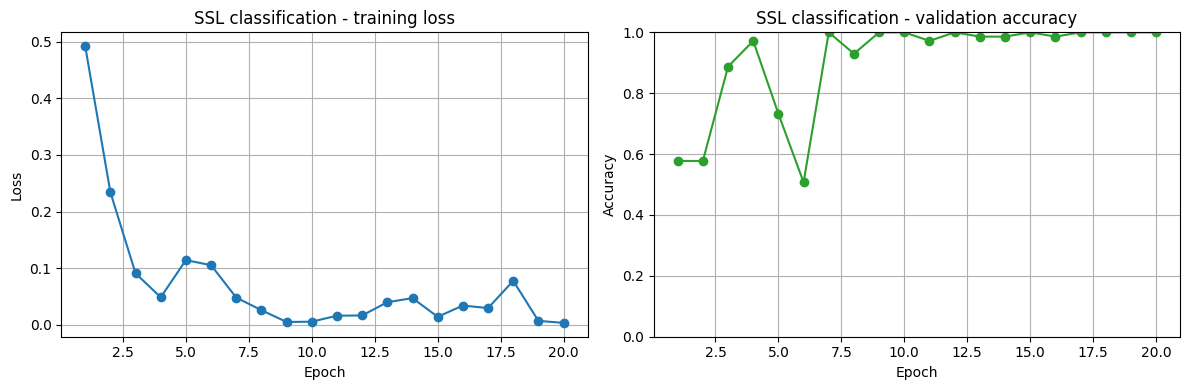

In [7]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker="o", color="tab:blue")
plt.title("SSL classification - training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, marker="o", color="tab:green")
plt.title("SSL classification - validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.grid(True)

plt.tight_layout()
plt.show()
